In [1]:
from pathlib import Path
from shutil import rmtree
from math import ceil
from json import dump
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV
from sklearn.tree import DecisionTreeClassifier
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import make_column_transformer, make_column_selector
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix
from sklearn.metrics import roc_curve, auc, RocCurveDisplay
from sklearn.metrics import precision_recall_curve, average_precision_score
from sklearn.metrics import PrecisionRecallDisplay
from sklearn.utils.class_weight import compute_sample_weight

RANDOM_STATE = 12345

# Data

In [2]:
def get_cache_dir(parent_dir: Path, cache_dir_name: str) -> str:
    cache_dir = parent_dir / cache_dir_name
    if cache_dir.is_dir():
        rmtree(cache_dir, ignore_errors=True)
    cache_dir.mkdir(exist_ok=True)
    return str(cache_dir)

In [3]:
# Training data
train_data = Path("../datasense/dataset/datasense_full_train_1sec.parquet")
train_data = pd.read_parquet(train_data)
X_train = train_data
y_train = train_data["label4"]
sample_weight = compute_sample_weight("balanced", train_data["label_extended"])

# Results directory
results_dir = Path("results/decision_tree/")
results_dir.mkdir(exist_ok=True, parents=True)

# Cache directory for pipeline memoization
cache_dir = get_cache_dir(results_dir, ".cache")

# Experiments

## Training pipe

In [4]:
train_pipe = Pipeline(
    steps=[
        (
            "transformations",
            make_column_transformer(
                ("drop", make_column_selector(r"^label")),
                (OneHotEncoder(drop="first"), ["device_type"]),
                ("drop", make_column_selector(dtype_exclude="number")),
                remainder="passthrough",
                verbose_feature_names_out=False,
            ),
        ),
        (
            "model", DecisionTreeClassifier(random_state=RANDOM_STATE),
        ),
    ],
    memory=str(cache_dir),
    verbose=False,
)

## Grid seach cross-validations

In [5]:
param_grid = {
    # "model__criterion": ["gini", "entropy"],
    # "model__splitter": ["best", "random"],
    "model__max_depth": [8, 16],
    # "model__max_features": [None, "log2"],
}

In [6]:
grid = GridSearchCV(
    train_pipe,
    param_grid,
    scoring="f1_macro",
    n_jobs=3,
    refit=True,
    cv=10,
    verbose=0,
    return_train_score=True,
)

grid.fit(X_train, y_train, model__sample_weight=sample_weight)
trained_model = grid.best_estimator_
trained_model

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('transformations', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",'results/decision_tree/.cache'
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('drop-1', ...), ('onehotencoder', ...), ...]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'passthrough'
,"sparse_threshold sparse_threshold: float, def

# Evaluations

In [7]:
del X_train, y_train

test_data = Path("../datasense/dataset/datasense_full_test_1sec.parquet")
test_data = pd.read_parquet(test_data)
X_test = test_data
y_test = test_data["label4"]

In [8]:
y_pred = trained_model.predict(X_test)
y_proba = trained_model.predict_proba(X_test)

## Classification report

In [9]:
results = classification_report(y_test, y_pred, zero_division=0, output_dict=True)

with (results_dir / "report.json").open("w") as f:
    dump(results, f, indent=4)

print(classification_report(y_test, y_pred, zero_division=0))

                                   precision    recall  f1-score   support

                           benign       0.92      0.88      0.90     34200
        bruteforce_dictionary-ssh       0.70      0.48      0.57       240
     bruteforce_dictionary-telnet       0.54      0.42      0.47       225
    ddos_ack-frag-flood-port-1883       0.82      0.92      0.87       232
      ddos_ack-frag-flood-port-80       0.94      0.61      0.74       168
               ddos_connect-flood       0.00      0.00      0.00        15
        ddos_http-flood-port-1883       0.98      0.85      0.91       225
          ddos_http-flood-port-80       0.61      0.80      0.69       167
                  ddos_icmp-flood       0.97      0.87      0.92       400
             ddos_icmp-frag-flood       0.93      0.87      0.90       395
          ddos_mqtt-publish-flood       0.00      0.00      0.00        15
    ddos_push-ack-flood-port-1883       0.97      0.93      0.95       231
      ddos_push-ack-floo

## Confusion matrix

In [10]:
cm = confusion_matrix(y_test, y_pred, normalize="true")

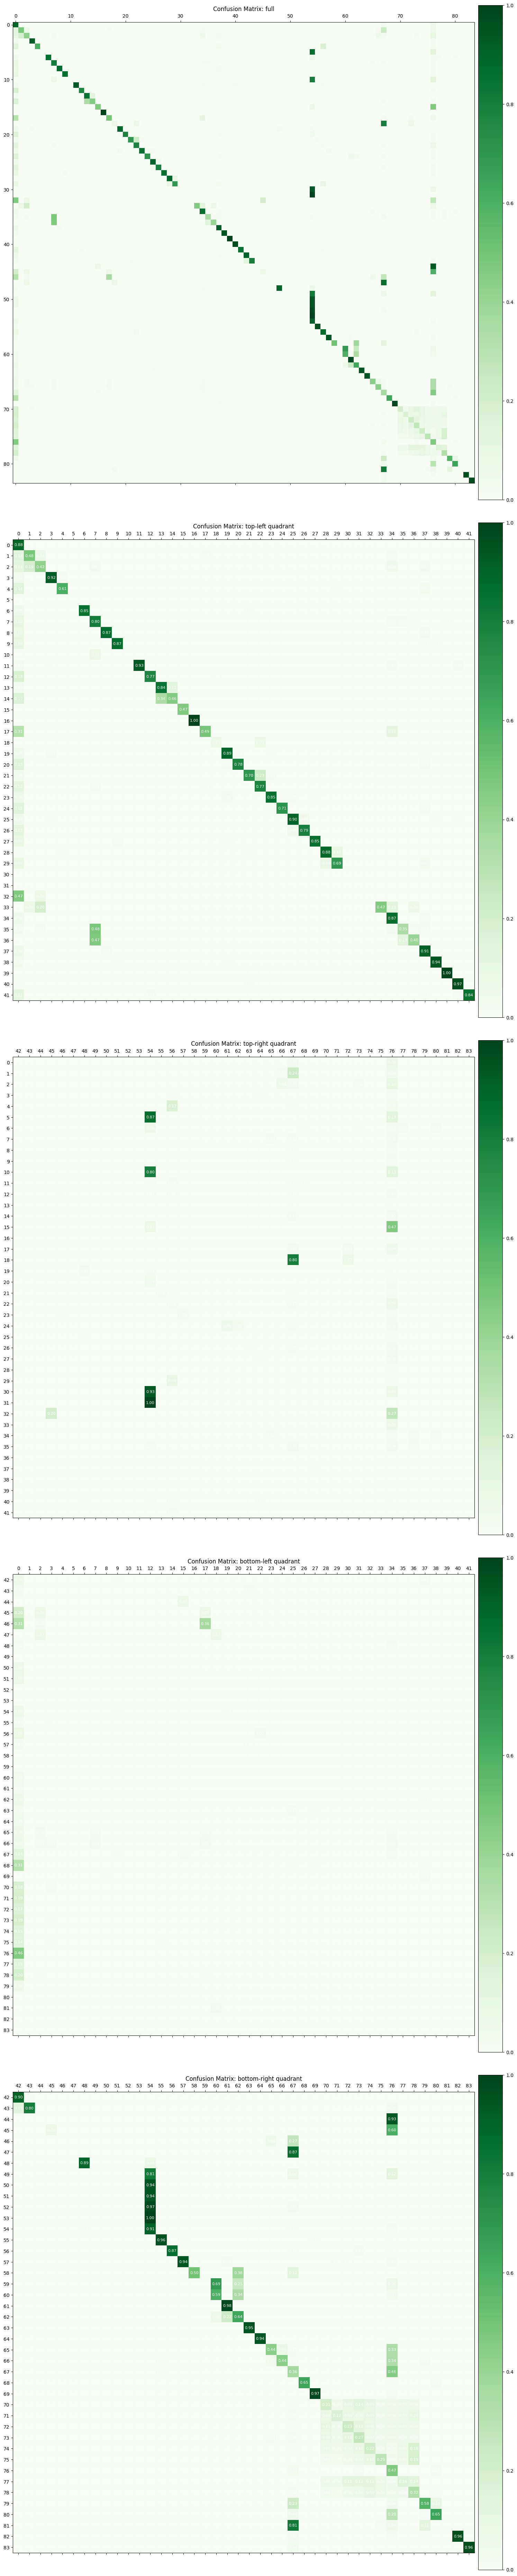

In [11]:
fig, axs = plt.subplots(5, 2, figsize=(15, 75), width_ratios=[19, 1])
axs_cbars = axs[:, 1]
axs = axs[:, 0]

# Full matrix
img = axs[0].matshow(cm, cmap="Greens", vmin=0, vmax=1)
axs[0].set_title("Confusion Matrix: full")
plt.colorbar(img, cax=axs_cbars[0])
# Quadrants
cm_mid = len(cm) // 2
lft_ticks = list(range(cm_mid))
rgt_ticks = list(range(cm_mid, len(cm)))
top_ticks = lft_ticks
btm_ticks = rgt_ticks
## Top-left
img = axs[1].matshow(cm[:cm_mid, :cm_mid], cmap="Greens", vmin=0, vmax=1)
axs[1].set_title("Confusion Matrix: top-left quadrant")
axs[1].set_xticks(lft_ticks)
axs[1].set_yticks(top_ticks)
plt.colorbar(img, cax=axs_cbars[1])
## Top-right
img = axs[2].matshow(cm[:cm_mid, cm_mid:], cmap="Greens", vmin=0, vmax=1)
axs[2].set_title("Confusion Matrix: top-right quadrant")
axs[2].set_xticks(range(len(rgt_ticks)), labels=rgt_ticks)
axs[2].set_yticks(top_ticks)
plt.colorbar(img, cax=axs_cbars[2])
## Bottom-left
img = axs[3].matshow(cm[cm_mid:, :cm_mid], cmap="Greens", vmin=0, vmax=1)
axs[3].set_title("Confusion Matrix: bottom-left quadrant")
axs[3].set_xticks(lft_ticks)
axs[3].set_yticks(range(len(btm_ticks)), labels=btm_ticks)
plt.colorbar(img, cax=axs_cbars[3])
## Bottom-right
img = axs[4].matshow(cm[cm_mid:, cm_mid:], cmap="Greens", vmin=0, vmax=1)
axs[4].set_title("Confusion Matrix: bottom-right quadrant")
axs[4].set_xticks(range(len(rgt_ticks)), labels=rgt_ticks)
axs[4].set_yticks(range(len(btm_ticks)), labels=btm_ticks)
plt.colorbar(img, cax=axs_cbars[4])

for i in range(len(cm)):
    in_first_half = i < cm_mid
    i_mod = i % cm_mid
    for j in range(len(cm)):
        if in_first_half:
            if j < cm_mid:
                ax = axs[1]
            else:
                ax = axs[2]
        else:
            if j < cm_mid:
                ax = axs[3]
            else:
                ax = axs[4]
        val = f"{cm[i, j]:4.2f}"
        ax.text(
            j % cm_mid,
            i_mod,
            val,
            ha="center", va="center",
            color="white", fontsize=8,
        )

plt.tight_layout()
plt.savefig(results_dir / "confusion_matrix.png", dpi=300)
plt.show()

# ROC curves

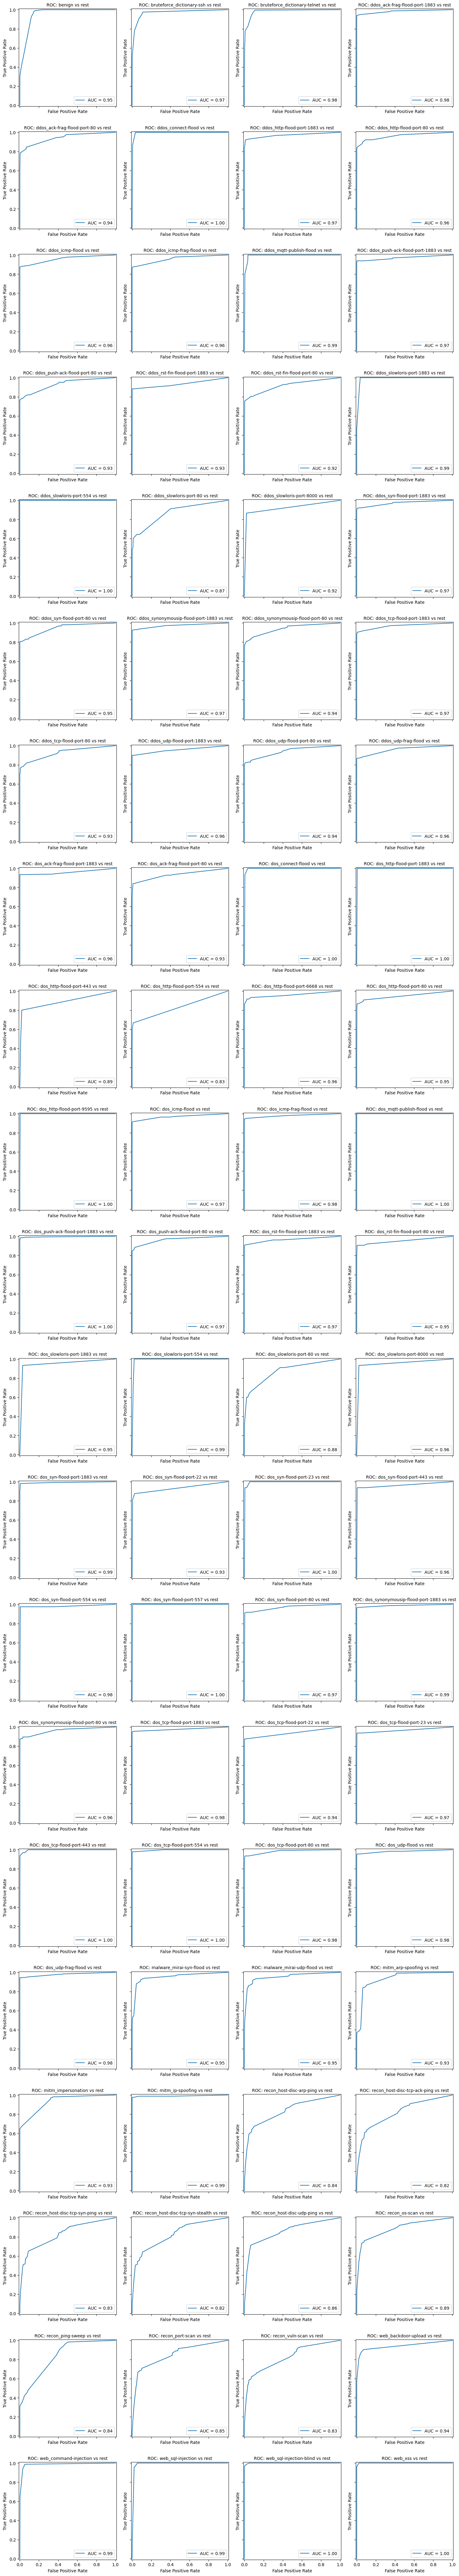

In [12]:
ncols = 4
nrows = ceil(len(trained_model.classes_) / ncols)

fig, axs = plt.subplots(nrows, ncols, figsize=(15, nrows*4), sharex=True, sharey=True)
axs = axs.flatten()

for i, cls_label in enumerate(trained_model.classes_):
    cls_y_true = y_test == cls_label
    cls_y_proba = y_proba[:, i]
    fpr, tpr, _ = roc_curve(cls_y_true, cls_y_proba)
    roc_auc = auc(fpr, tpr)
    disp = RocCurveDisplay(fpr=fpr, tpr=tpr, roc_auc=roc_auc)
    disp.plot(ax=axs[i])
    axs[i].set_title(f"ROC: {cls_label} vs rest", fontsize=10)

plt.tight_layout()
plt.savefig(results_dir / "roc_curves.png", dpi=300)
plt.show()

# Precision-recall curves

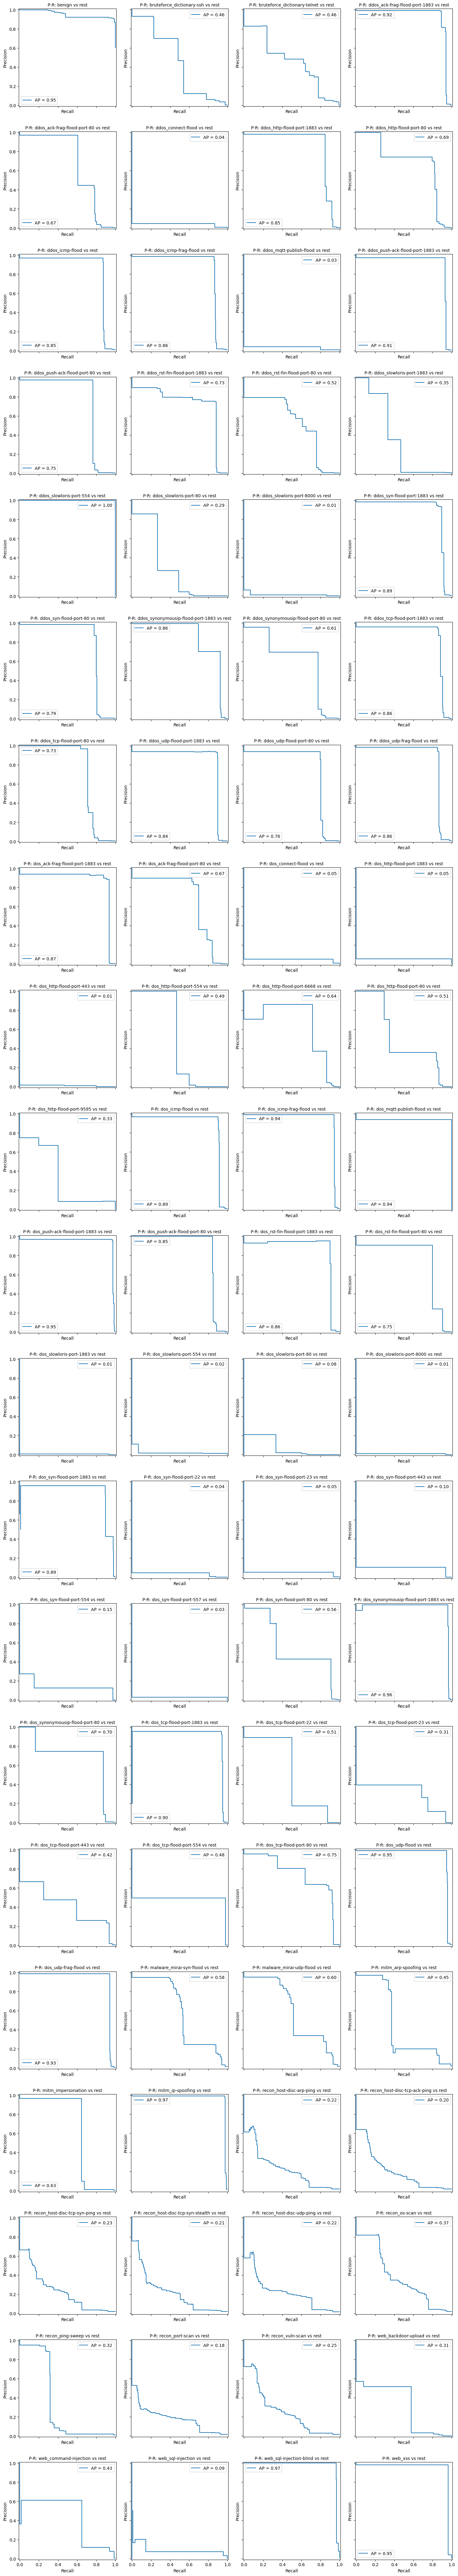

In [13]:
fig, axs = plt.subplots(nrows, ncols, figsize=(15, nrows*4), sharex=True, sharey=True)
axs = axs.flatten()

for i, cls_label in enumerate(trained_model.classes_):
    cls_y_true = y_test == cls_label
    cls_y_proba = y_proba[:, i]
    precision, recall, _ = precision_recall_curve(cls_y_true, cls_y_proba)
    ap = average_precision_score(cls_y_true, cls_y_proba)
    disp = PrecisionRecallDisplay(precision=precision, recall=recall)
    disp.plot(ax=axs[i], label=f"AP = {ap:.2f}")
    axs[i].legend(loc="best")
    axs[i].set_title(f"P-R: {cls_label} vs rest", fontsize=10)

plt.tight_layout()
plt.savefig(results_dir / "precision_recall_curves.png", dpi=300)
plt.show()